# 01: EDA of the St. Petersburg long-term rental market
CIAN snapshot from 2026-07-02, after cleaning (`src/cleaning/clean.py`).
Goal: understand the price distribution, the key relationships, and record findings for the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
C = '#2b6cb0'

df = pd.read_parquet('../data/processed/listings.parquet')
spb = df[df.is_lenobl == 0]
print(f'total: {len(df)}, SPb: {len(spb)}, Leningrad Oblast: {len(df) - len(spb)}')
df.head(3)

total: 11525, SPb: 9278, Leningrad Oblast: 2247


,offer_id,snapshot_date,price,deposit,client_fee_pct,agent_fee_pct,utilities_included,rooms,flat_type,is_apartments,...,description,rooms_n,is_studio,is_lenobl,price_per_m2,source,is_suspicious_cheap,n_clones,n_platforms,cross_platform
0,330969414,2026-07-02,28000,10000.0,0.0,0.0,0.0,3.0,rooms,0.0,...,Сдаётся уютная трехкомнатная квартира. В пешей...,3.0,0,1,500.000000,cian,0,1,1,0
1,330900554,2026-07-02,15000,NaN,70.0,0.0,0.0,1.0,rooms,0.0,...,Сдам тёплую однокомнатную квартиру площадью 3...,1.0,0,1,468.750000,cian,0,1,1,0
2,329227323,2026-07-02,45000,20.0,100.0,50.0,0.0,3.0,rooms,NaN,...,Арт. 134899662 Квартира сдается любым категори...,3.0,0,1,818.181818,cian,0,1,1,0


## Cleaning losses
Full report: `data/processed/cleaning_report.md`.

In [2]:
from pathlib import Path
print(Path('../data/processed/cleaning_report.md').read_text())

# Data cleaning report

Snapshot: 2026-07-02. Input: 11978 listings, output: 11525.

| Filter | Rows dropped | Remaining |
|---|---:|---:|
| initial | - | 11978 |
| price outside [8000, 350000] RUB/mo | 42 | 11936 |
| area outside [10.0, 200.0] m2 | 34 | 11902 |
| no coordinates | 0 | 11902 |
| price/m2 outside [300.0, 6000.0] RUB | 12 | 11890 |
| room count undetermined | 0 | 11890 |
| coordinates outside the SPb agglomeration | 185 | 11705 |
| duplicates (agencies + cross-platform) | 180 | 11525 |

Flagged (not removed):
- suspiciously cheap (< 50% of the district median): 104
- apart-hotels: 562
- Leningrad Oblast: 2247
- by source: {'cian': np.int64(11525)}
- cross-platform (flat on both CIAN and Yandex): 0



## Price distribution is log-normal (the argument for a log target)

median: 43000 RUB, mean: 55316 RUB (the right tail pulls the mean up)


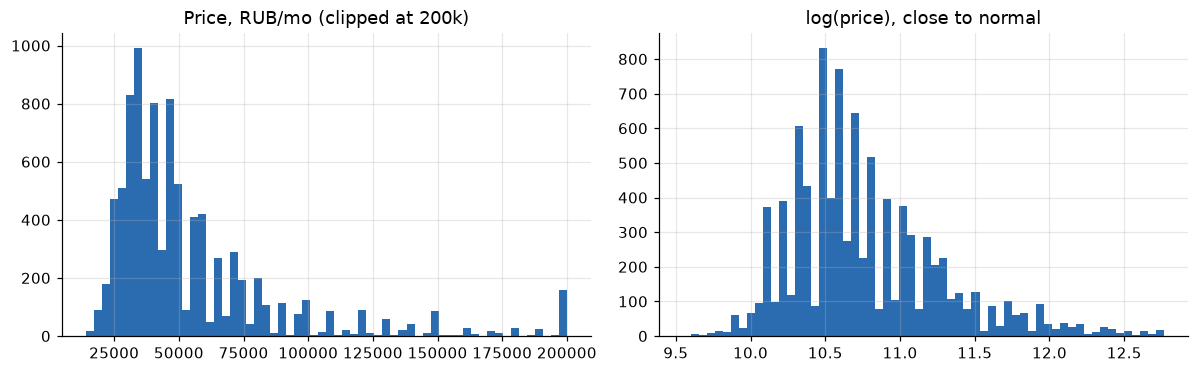

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
spb.price.clip(upper=200_000).hist(bins=60, ax=axes[0], color=C)
axes[0].set_title('Price, RUB/mo (clipped at 200k)')
np.log(spb.price).hist(bins=60, ax=axes[1], color=C)
axes[1].set_title('log(price), close to normal')
plt.tight_layout()
print('median: %d RUB, mean: %d RUB (the right tail pulls the mean up)' % (spb.price.median(), spb.price.mean()))

## Price per m2 by district, the main geo signal

spread across districts: 760-1895 RUB/m2, x2.5


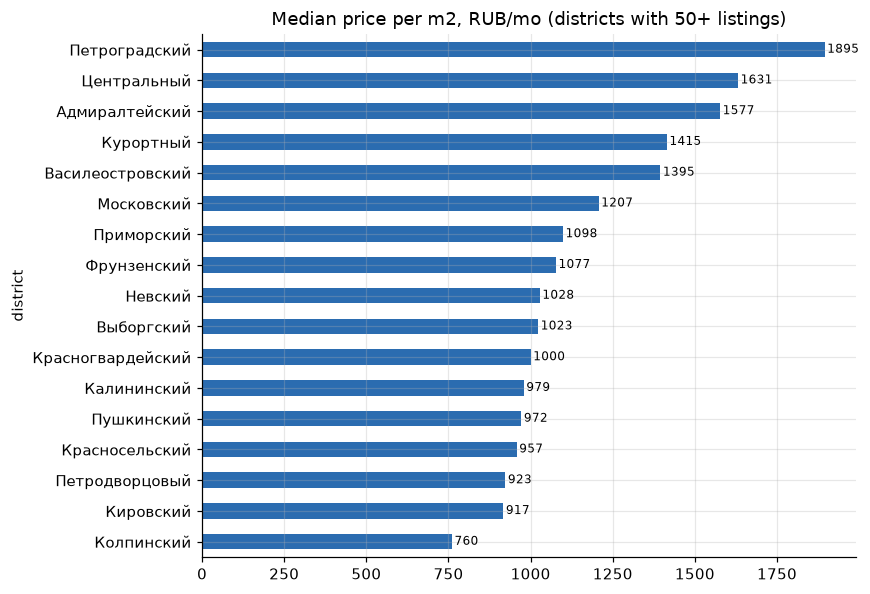

In [4]:
ppm = (spb.groupby('district').price_per_m2.agg(['median', 'count'])
       .query('count >= 50').sort_values('median'))
fig, ax = plt.subplots(figsize=(8, 5.5))
ppm['median'].plot.barh(ax=ax, color=C)
ax.set_title('Median price per m2, RUB/mo (districts with 50+ listings)')
ax.set_xlabel('')
for i, (v, n) in enumerate(zip(ppm['median'], ppm['count'])):
    ax.text(v + 8, i, f'{v:.0f}', va='center', fontsize=8)
plt.tight_layout()
print('spread across districts: %.0f-%.0f RUB/m2, x%.1f' % (ppm['median'].min(), ppm['median'].max(), ppm['median'].max()/ppm['median'].min()))

## Price by room count

studio: median   33,000 RUB  (n=2312)
     1: median   40,000 RUB  (n=3751)
     2: median   55,000 RUB  (n=2260)
     3: median   80,000 RUB  (n=805)
    4+: median  130,000 RUB  (n=150)


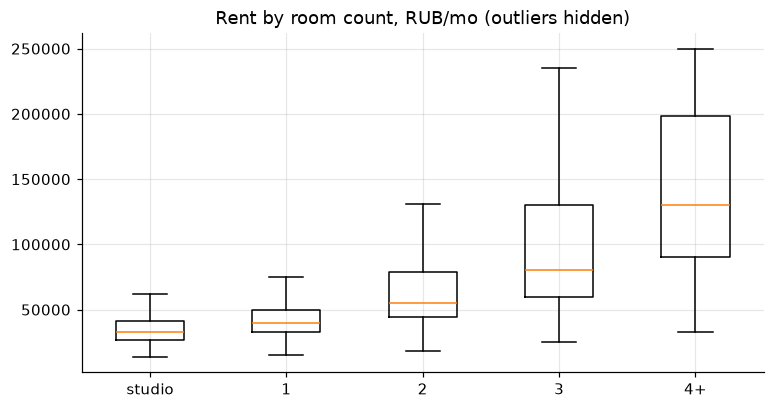

In [5]:
order = ['studio', '1', '2', '3', '4+']
spb2 = spb.assign(rooms_cat=np.select(
    [spb.is_studio == 1, spb.rooms_n == 1, spb.rooms_n == 2, spb.rooms_n == 3],
    ['studio', '1', '2', '3'], default='4+'))
data = [spb2[spb2.rooms_cat == c].price.clip(upper=250_000) for c in order]
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, showfliers=False)
ax.set_xticklabels(order)
ax.set_title('Rent by room count, RUB/mo (outliers hidden)')
for c in order:
    s = spb2[spb2.rooms_cat == c].price
    print(f'{c:>6}: median {s.median():>8,.0f} RUB  (n={len(s)})')

## Metro: every minute on foot costs money

"near metro" premium (<=5 min vs 20-30): 15%

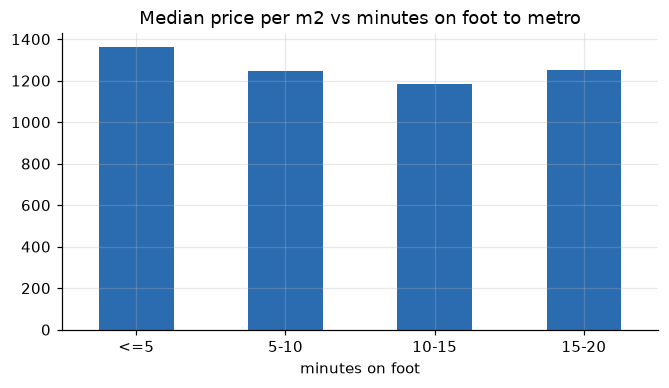

In [6]:
walk = spb[(spb.metro_transport == 'walk') & spb.metro_time_min.notna()].copy()
walk['bin'] = pd.cut(walk.metro_time_min, [0, 5, 10, 15, 20, 30, 60],
                     labels=['<=5', '5-10', '10-15', '15-20', '20-30', '30+'])
g = walk.groupby('bin', observed=True).price_per_m2.median()
fig, ax = plt.subplots(figsize=(7, 3.5))
g.plot.bar(ax=ax, color=C, rot=0)
ax.set_title('Median price per m2 vs minutes on foot to metro')
ax.set_xlabel('minutes on foot')
print('"near metro" premium (<=5 min vs 20-30): %.0f%%' % ((g.iloc[0]/g.iloc[-2] - 1) * 100))

## Area vs price

corr(log(area), log(price)) = 0.72


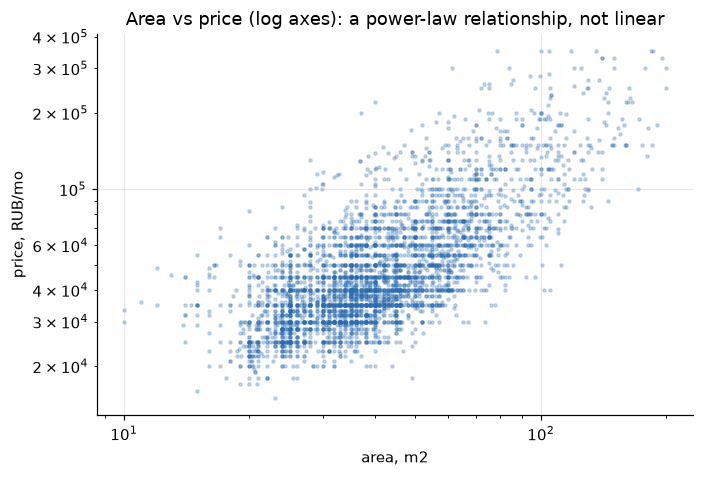

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
s = spb.sample(min(4000, len(spb)), random_state=42)
ax.scatter(s.total_area, s.price, s=4, alpha=0.25, color=C)
ax.set_yscale('log'); ax.set_xscale('log')
ax.set_xlabel('area, m2'); ax.set_ylabel('price, RUB/mo')
ax.set_title('Area vs price (log axes): a power-law relationship, not linear')
corr = np.corrcoef(np.log(spb.total_area), np.log(spb.price))[0, 1]
print(f'corr(log(area), log(price)) = {corr:.2f}')

## Owner vs agent

In [8]:
g = spb.groupby('is_by_homeowner').agg(
    n=('price', 'size'), median_price=('price', 'median'),
    median_per_m2=('price_per_m2', 'median'))
g.index = ['agent', 'owner']
print(g)
print()
lo = df[df.is_lenobl == 1]
print(f'Leningrad Oblast: median {lo.price.median():,.0f} RUB vs SPb {spb.price.median():,.0f} RUB '
      f'(discount {(1 - lo.price.median()/spb.price.median())*100:.0f}%)')

          n  median_price  median_per_m2
agent  4506       42000.0    1070.422535
owner  3069       42000.0    1152.073733

Leningrad Oblast: median 28,000 RUB vs SPb 43,000 RUB (discount 35%)


## Takeaways for the model
1. **A log target is a must**: the price distribution is log-normal, with a tail up to 350k.
2. **Geography is signal number one**: the median price per m2 varies several-fold between districts; district, coordinates, and minutes to metro should all go into the model.
3. **Room count is non-linear**: a studio is close to a one-room flat in price per m2, then price per m2 falls while total price rises, which supports choosing trees over a linear model.
4. **Metro**: the premium for 5 minutes on foot or less is clear, so distance to metro goes in as a continuous feature.
5. **Owner vs agent**: there is a price difference, so the flag goes into the model.
6. **Leningrad Oblast is cheaper**: the `is_lenobl` flag is required, otherwise the model blurs the city boundary.
7. The `is_suspicious_cheap` flags (104 of them) are scam candidates: exclude them from train, but run them through the overpricing detector as negative examples.